## AWI Analysis , Position Breakdown, Player Leaderboard, Team Comparison

Loads `results/awi_full.csv` (unified pipeline output: AWI + HBD + pre-pass AWI + scan direction).  
Falls back to `results/awi_all_matches.csv` if the full file is not yet available.  
Filters to active players (coverage_pct >= 0.5 = tracked for >=50% of the phase).  
Position codes are DFL German abbreviations, grouped into 7 broad roles.


Loaded: ../results/awi_full.csv
Total rows: 400 | Active (coverage >= 50%): 168
Zero-AWI rows excluded: 202 (50% of all rows)

AWI by position group (active players, coverage >= 50%):
            mean  median   std   n
pos_group                         
GK          5.86    5.46  2.31  12
CB         13.52   12.79  2.41  33
FB         11.77   11.84  2.98   9
DM         16.04   17.22  5.51  43
CM         11.29    9.97  4.36  13
WM         12.37   13.70  4.00  18
FW         12.71   12.58  4.10  24

Top 20 players by average AWI:
                         name pos_group      mean  phases
         Hugo Emanuel Larsson        DM 26.260000       1
                 Rani Khedira        DM 22.610000       2
        Oscar Winther Höjlund        DM 22.326667       3
        Joshua Walter Kimmich        DM 22.100000       3
             Aljoscha Kemlein        DM 21.190000       2
               Rayan Philippe        FW 20.010000       1
           Oliver Jasen Burke        FW 19.610000       1
     

/var/folders/d8/jdj9dp996ps5f3y5m79s3j3m0000gn/T/ipykernel_3484/2203512090.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(plot_data, labels=groups_present, patch_artist=True,


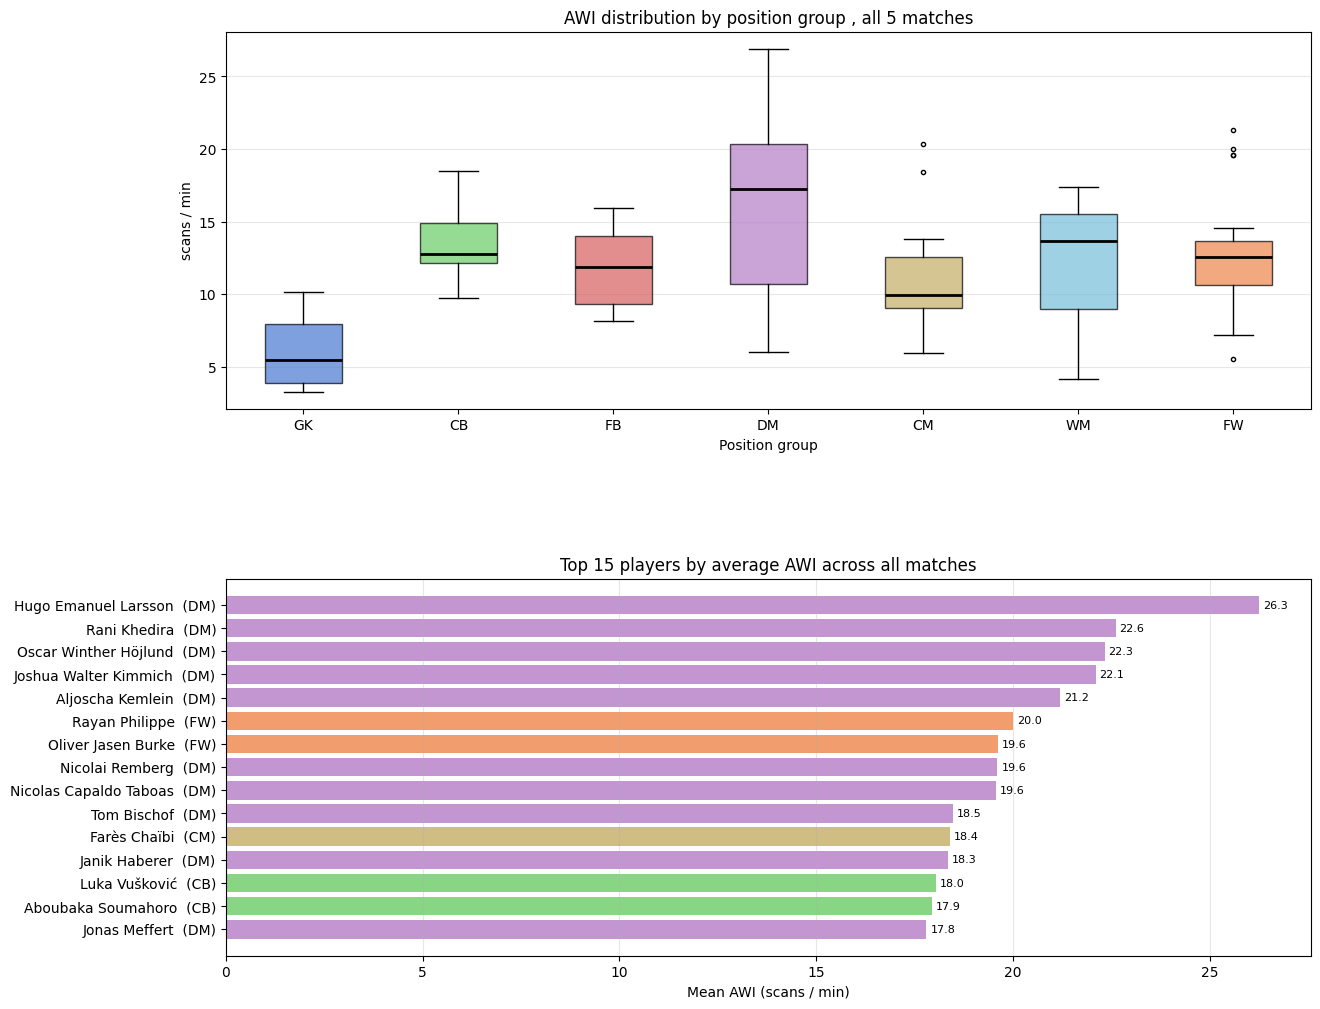

Saved: ../figures/awi_analysis.png


In [1]:
import os, sys
from pathlib import Path

# Find project root (pyproject.toml marker) and chdir to notebooks/
# so ../results/ and ../figures/ resolve correctly from any launch CWD.
_root = next(
    (p for p in [Path().resolve(), *Path().resolve().parents] if (p / "pyproject.toml").exists()),
    None,
)
if _root is None:
    raise RuntimeError("Cannot locate project root  -  pyproject.toml not found.")
os.chdir(_root / "notebooks")
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

# Cell 10: AWI analysis , position breakdown, player leaderboard, team comparison

import sys, os

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

os.makedirs("../figures", exist_ok=True)

# Load results , prefer awi_full.csv (unified pipeline), fall back to awi_all_matches.csv
if os.path.exists("../results/awi_full.csv"):
    df = pd.read_csv("../results/awi_full.csv")
    print("Loaded: ../results/awi_full.csv")
elif os.path.exists("../results/awi_all_matches.csv"):
    df = pd.read_csv("../results/awi_all_matches.csv")
    print("Loaded: ../results/awi_all_matches.csv (no awi_full.csv yet , run unified pipeline)")
else:
    raise FileNotFoundError(
        "No results file found. Run Cell 2 in run_pipeline.ipynb to generate ../results/awi_full.csv."
    )

# Filter: exclude substitutes and players with low skeleton coverage.
# coverage_pct < 0.5 means tracked for <50% of the phase (~25 min of a half).
active = df[df["coverage_pct"] >= 0.5].copy()
print(f"Total rows: {len(df)} | Active (coverage >= 50%): {len(active)}")
print(f"Zero-AWI rows excluded: {(df['awi_per_minute'] == 0).sum()} "
      f"({(df['awi_per_minute'] == 0).mean():.0%} of all rows)\n")

# Map DFL German position codes to broad role groups
POS_GROUP = {
    "TW":  "GK",
    "IVL": "CB",  "IVR": "CB",  "IVZ": "CB",
    "LV":  "FB",  "RV":  "FB",
    "DML": "DM",  "DMR": "DM",  "DMZ": "DM",  "DLM": "DM",  "DRM": "DM",
    "HL":  "CM",  "HR":  "CM",  "ZO":  "CM",  "RM":  "CM",
    "OLM": "WM",  "ORM": "WM",  "OHL": "WM",  "OHR": "WM",
    "RA":  "FW",  "LA":  "FW",  "STL": "FW",  "STR": "FW",  "STZ": "FW",
}
GROUP_ORDER = ["GK", "CB", "FB", "DM", "CM", "WM", "FW"]
active["pos_group"] = active["position"].map(POS_GROUP).fillna("Unknown")

# ── 1. AWI by position group ─────────────────────────────────────────────────
pos_stats = (
    active[active["pos_group"].isin(GROUP_ORDER)]
    .groupby("pos_group")["awi_per_minute"]
    .agg(mean="mean", median="median", std="std", n="count")
    .reindex(GROUP_ORDER)
    .round(2)
)
print("AWI by position group (active players, coverage >= 50%):")
print(pos_stats.to_string())

# ── 2. Player leaderboard ───────────────────────────────────────────────────
# Average AWI across all phases a player appeared in.
leaderboard = (
    active
    .groupby(["name", "pos_group"])["awi_per_minute"]
    .agg(mean="mean", phases="count")
    .reset_index()
    .sort_values("mean", ascending=False)
)
print("\nTop 20 players by average AWI:")
print(leaderboard.head(20).to_string(index=False))

# ── 3. Match-level team comparison ──────────────────────────────────────────
TEAM_NAMES = {
    ("FCB-HSV", 1): "Bayern",    ("FCB-HSV", 0): "Hamburg",
    ("BVB-VFB", 1): "Dortmund",  ("BVB-VFB", 0): "Stuttgart",
    ("SGE-FCB", 1): "Frankfurt", ("SGE-FCB", 0): "Bayern",
    ("SGE-FCU", 1): "Frankfurt", ("SGE-FCU", 0): "Union",
    ("FCU-FCB", 1): "Union",     ("FCU-FCB", 0): "Bayern",
}
active["team_name"] = active.apply(lambda r: TEAM_NAMES.get((r["match_id"], r["team"]), "?"), axis=1)
team_match = (
    active.groupby(["match_id", "team_name"])["awi_per_minute"]
    .mean()
    .round(2)
    .reset_index()
    .sort_values(["match_id", "team_name"])
)
print("\nMean AWI by team per match:")
print(team_match.to_string(index=False))

# ── 4. Visualisation ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# 4a. Boxplot by position group
ax1 = fig.add_subplot(gs[0, :])
groups_present = [g for g in GROUP_ORDER if g in active["pos_group"].values]
plot_data = [active.loc[active["pos_group"] == g, "awi_per_minute"].values for g in groups_present]
bp = ax1.boxplot(plot_data, labels=groups_present, patch_artist=True,
                 medianprops=dict(color="black", linewidth=2), flierprops=dict(markersize=3))
colors = ["#4878d0", "#6acc65", "#d65f5f", "#b47cc7", "#c4ad66", "#77bedb", "#ee854a"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_title("AWI distribution by position group , all 5 matches", fontsize=12)
ax1.set_ylabel("scans / min")
ax1.set_xlabel("Position group")
ax1.grid(axis="y", alpha=0.3)

# 4b. Top 15 player leaderboard
ax2 = fig.add_subplot(gs[1, :])
top15 = leaderboard.head(15)
bar_colors = [colors[GROUP_ORDER.index(g)] if g in GROUP_ORDER else "#aaaaaa"
              for g in top15["pos_group"]]
bars = ax2.barh(
    top15["name"] + "  (" + top15["pos_group"] + ")",
    top15["mean"],
    color=bar_colors,
    alpha=0.8,
)
ax2.invert_yaxis()
ax2.set_xlabel("Mean AWI (scans / min)")
ax2.set_title("Top 15 players by average AWI across all matches", fontsize=12)
ax2.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, top15["mean"]):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}", va="center", fontsize=8)

plt.savefig("../figures/awi_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../figures/awi_analysis.png")

## Half-by-Half Consistency

Does AWI hold up across both halves for the same player? High correlation validates the metric as a stable player trait rather than match noise.

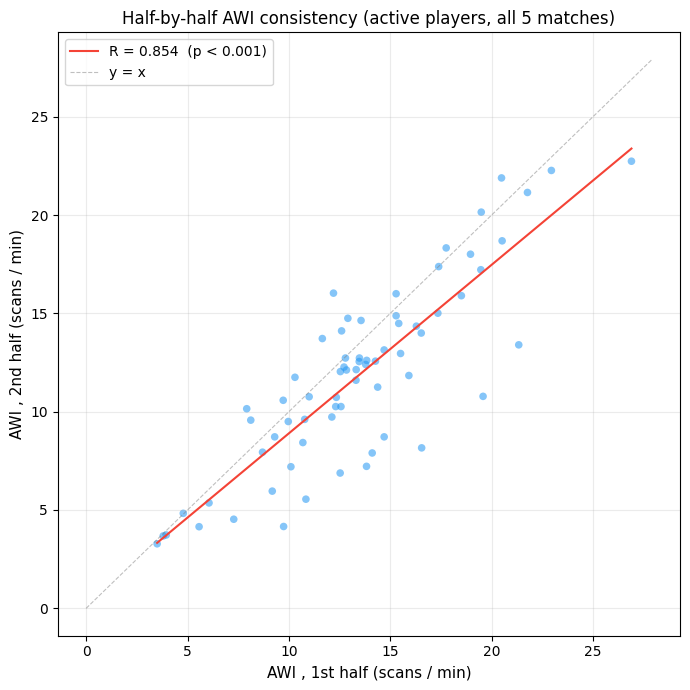

n = 69 player×match pairs  |  R = 0.854  |  p = 1.04e-20
Saved: ../figures/awi_consistency.png


In [2]:
# Cell 11: Half-by-half AWI consistency
#
# Pivots active players to (1st half, 2nd half) AWI per player × match.
# High correlation (R ≈ 0.85) validates AWI as a stable player trait.

import scipy.stats as stats

pivot = (
    active
    .pivot_table(index=["name", "match_id"], columns="phase_label", values="awi_per_minute")
    .dropna(subset=["1st half", "2nd half"])
    .reset_index()
)

r, p = stats.pearsonr(pivot["1st half"], pivot["2nd half"])

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(pivot["1st half"], pivot["2nd half"], alpha=0.55, s=30, color="#2196F3", edgecolors="none")

# Regression line
m, b = np.polyfit(pivot["1st half"], pivot["2nd half"], 1)
x_line = np.linspace(pivot["1st half"].min(), pivot["1st half"].max(), 100)
ax.plot(x_line, m * x_line + b, color="#F44336", lw=1.5, label=f"R = {r:.3f}  (p < 0.001)")

# Identity line
lim = max(pivot["1st half"].max(), pivot["2nd half"].max()) + 1
ax.plot([0, lim], [0, lim], color="grey", lw=0.8, ls="--", alpha=0.5, label="y = x")

ax.set_xlabel("AWI , 1st half (scans / min)", fontsize=11)
ax.set_ylabel("AWI , 2nd half (scans / min)", fontsize=11)
ax.set_title("Half-by-half AWI consistency (active players, all 5 matches)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("../figures/awi_consistency.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"n = {len(pivot)} player×match pairs  |  R = {r:.3f}  |  p = {p:.2e}")
print("Saved: ../figures/awi_consistency.png")

## Team & Home/Away Comparison

Which teams show the highest collective awareness? Away teams face unfamiliar environments , does that drive more scanning?

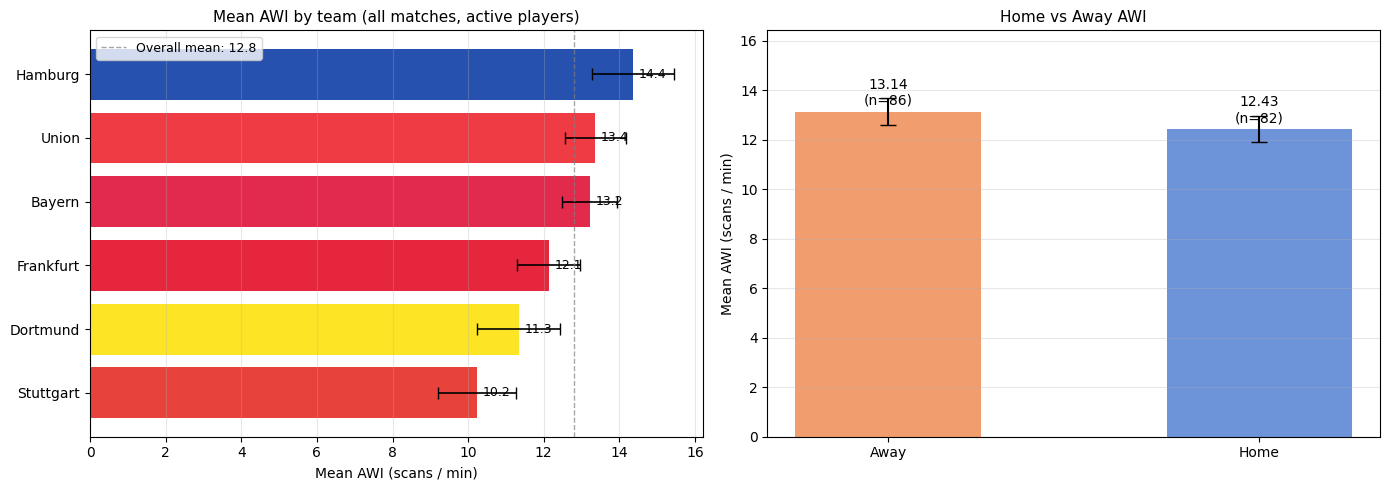

Saved: ../figures/awi_team_comparison.png


In [3]:
# Cell 12: Team AWI comparison + Home vs Away effect

TEAM_NAMES = {
    ("FCB-HSV", 1): "Bayern",    ("FCB-HSV", 0): "Hamburg",
    ("BVB-VFB", 1): "Dortmund",  ("BVB-VFB", 0): "Stuttgart",
    ("SGE-FCB", 1): "Frankfurt", ("SGE-FCB", 0): "Bayern",
    ("SGE-FCU", 1): "Frankfurt", ("SGE-FCU", 0): "Union",
    ("FCU-FCB", 1): "Union",     ("FCU-FCB", 0): "Bayern",
}
active["team_name"] = active.apply(lambda r: TEAM_NAMES.get((r["match_id"], r["team"]), "?"), axis=1)
active["side"] = active["team"].map({1: "Home", 0: "Away"})

team_stats = (
    active.groupby("team_name")["awi_per_minute"]
    .agg(mean="mean", sem=lambda x: x.std() / len(x) ** 0.5, n="count")
    .sort_values("mean", ascending=True)
    .reset_index()
)

TEAM_COLORS = {
    "Bayern": "#DC052D", "Hamburg": "#0033A0", "Dortmund": "#FDE100",
    "Stuttgart": "#E32219", "Frankfurt": "#E1001A", "Union": "#EB1923",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Team comparison
ax1 = axes[0]
bar_colors = [TEAM_COLORS.get(t, "#aaaaaa") for t in team_stats["team_name"]]
bars = ax1.barh(team_stats["team_name"], team_stats["mean"], xerr=team_stats["sem"],
                color=bar_colors, alpha=0.85, capsize=4, error_kw={"elinewidth": 1.2})
ax1.set_xlabel("Mean AWI (scans / min)", fontsize=10)
ax1.set_title("Mean AWI by team (all matches, active players)", fontsize=11)
ax1.axvline(active["awi_per_minute"].mean(), color="grey", lw=1, ls="--", alpha=0.7,
            label=f"Overall mean: {active['awi_per_minute'].mean():.1f}")
ax1.legend(fontsize=9)
ax1.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, team_stats["mean"]):
    ax1.text(val + 0.15, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}", va="center", fontsize=9)

# Panel 2: Home vs Away
ax2 = axes[1]
side_stats = active.groupby("side")["awi_per_minute"].agg(["mean", "sem", "count"])
side_colors = {"Home": "#4878d0", "Away": "#ee854a"}
for side, row in side_stats.iterrows():
    ax2.bar(side, row["mean"], yerr=row["sem"], color=side_colors[side],
            alpha=0.8, capsize=6, width=0.5, error_kw={"elinewidth": 1.5})
    ax2.text(side, row["mean"] + 0.15, f"{row['mean']:.2f}\n(n={int(row['count'])})",
             ha="center", va="bottom", fontsize=10)
ax2.set_ylabel("Mean AWI (scans / min)", fontsize=10)
ax2.set_title("Home vs Away AWI", fontsize=11)
ax2.set_ylim(0, max(side_stats["mean"]) * 1.25)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/awi_team_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../figures/awi_team_comparison.png")

## Position-Relative AWI (Z-Score)

Raw AWI is position-dependent , DMs scan more than GKs by design. Z-scoring within position group reveals which players *outperform their positional peers*, a fairer talent signal.

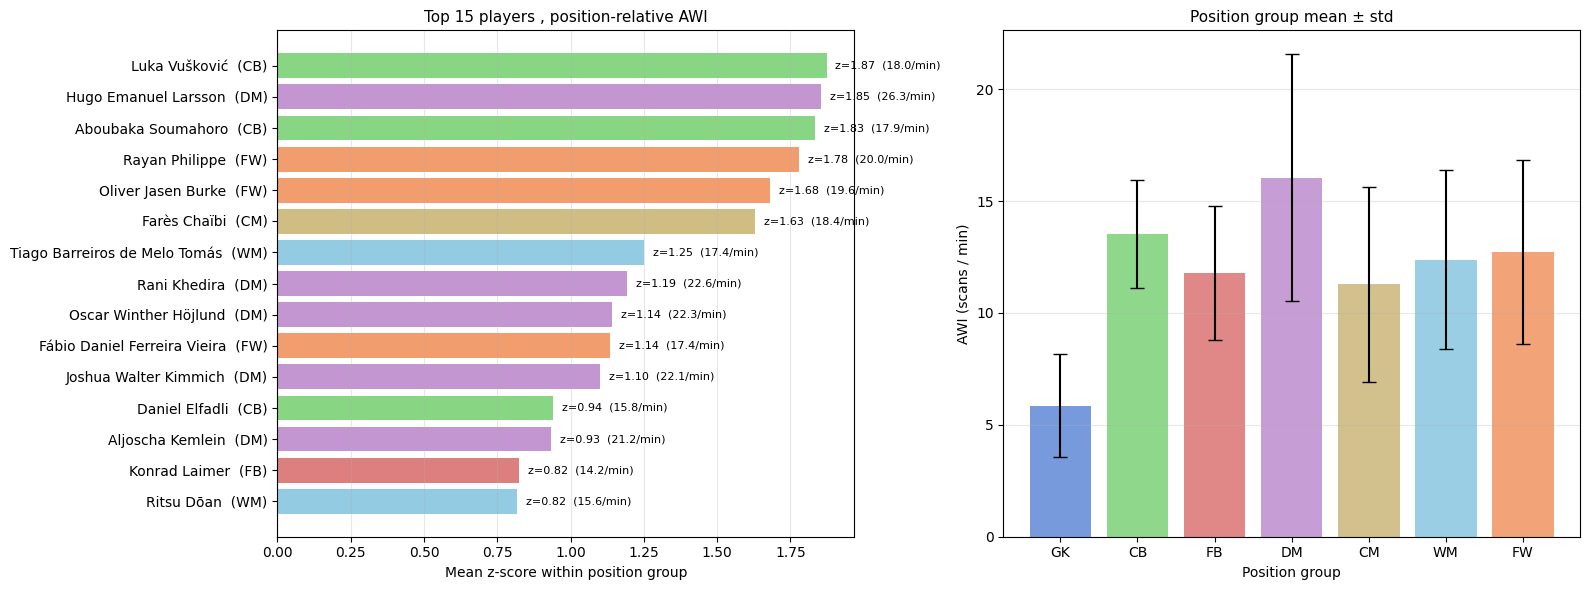

Top 15 players by position-relative AWI:
                         name pos_group  mean_awi   mean_z  phases
                Luka Vušković        CB 18.045000 1.873755       2
         Hugo Emanuel Larsson        DM 26.260000 1.854531       1
           Aboubaka Soumahoro        CB 17.950000 1.834409       1
               Rayan Philippe        FW 20.010000 1.778875       1
           Oliver Jasen Burke        FW 19.610000 1.681347       1
                 Farès Chaïbi        CM 18.390000 1.628752       1
Tiago Barreiros de Melo Tomás        WM 17.385000 1.251653       2
                 Rani Khedira        DM 22.610000 1.192349       2
        Oscar Winther Höjlund        DM 22.326667 1.140947       3
 Fábio Daniel Ferreira Vieira        FW 17.370000 1.135188       2
        Joshua Walter Kimmich        DM 22.100000 1.099825       3
               Daniel Elfadli        CB 15.790000 0.939796       1
             Aljoscha Kemlein        DM 21.190000 0.934733       2
                Konra

In [4]:
# Cell 13: Position-relative AWI (z-score within position group)
#
# Z-score = (player AWI - position group mean) / position group std.
# A CB with z=1.87 outperforms other CBs more than a DM with raw AWI=26.

active["pos_group"] = active["position"].map(POS_GROUP).fillna("Other")
active["awi_zscore"] = active.groupby("pos_group")["awi_per_minute"].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Aggregate per player (mean z-score across all phases)
player_z = (
    active[active["pos_group"].isin(GROUP_ORDER)]
    .groupby(["name", "pos_group"])
    .agg(mean_awi=("awi_per_minute", "mean"), mean_z=("awi_zscore", "mean"), phases=("awi_zscore", "count"))
    .reset_index()
    .sort_values("mean_z", ascending=False)
)

top_z = player_z.head(15)
bot_z = player_z.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Top 15 by z-score
ax1 = axes[0]
z_colors = [colors[GROUP_ORDER.index(g)] if g in GROUP_ORDER else "#aaaaaa" for g in top_z["pos_group"]]
bars1 = ax1.barh(
    top_z["name"] + "  (" + top_z["pos_group"] + ")",
    top_z["mean_z"],
    color=z_colors, alpha=0.8,
)
ax1.invert_yaxis()
ax1.axvline(0, color="grey", lw=0.8, ls="--")
ax1.set_xlabel("Mean z-score within position group", fontsize=10)
ax1.set_title("Top 15 players , position-relative AWI", fontsize=11)
ax1.grid(axis="x", alpha=0.3)
for bar, z, awi in zip(bars1, top_z["mean_z"], top_z["mean_awi"]):
    ax1.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height() / 2,
             f"z={z:.2f}  ({awi:.1f}/min)", va="center", fontsize=8)

# Panel 2: Position group mean ± std (distribution reference)
ax2 = axes[1]
pos_summary = (
    active[active["pos_group"].isin(GROUP_ORDER)]
    .groupby("pos_group")["awi_per_minute"]
    .agg(mean="mean", std="std")
    .reindex(GROUP_ORDER)
)
pos_bar_colors = [colors[i] for i in range(len(GROUP_ORDER))]
ax2.bar(pos_summary.index, pos_summary["mean"], yerr=pos_summary["std"],
        color=pos_bar_colors, alpha=0.75, capsize=5, error_kw={"elinewidth": 1.5})
ax2.set_xlabel("Position group", fontsize=10)
ax2.set_ylabel("AWI (scans / min)", fontsize=10)
ax2.set_title("Position group mean ± std", fontsize=11)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/awi_position_relative.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 15 players by position-relative AWI:")
print(player_z.head(15)[["name", "pos_group", "mean_awi", "mean_z", "phases"]].to_string(index=False))
print("\nSaved: ../figures/awi_position_relative.png")

## Pre-Pass AWI Analysis

Does higher awareness in the 5 seconds before a pass correlate with full-phase AWI?  
Requires `results/awi_full.csv` , generated by the unified pipeline (Cell 2 of run_pipeline.ipynb).


Rows with pre-pass AWI (n_passes >= 5): 127
Correlation full-phase AWI vs pre-pass AWI: R=0.750 (p=3.80e-24)


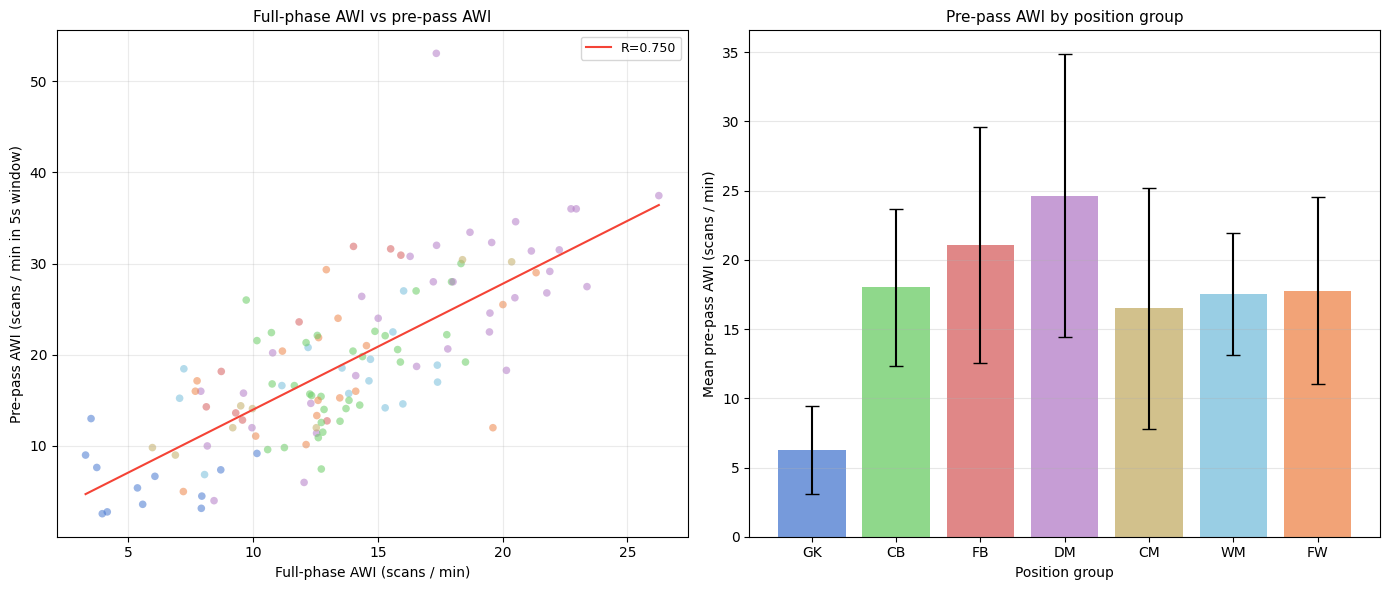

Saved: ../figures/awi_pre_pass.png


In [5]:
# Cell 14 (updated): Pre-pass AWI analysis
# Reads pre_pass_awi from awi_full.csv (unified pipeline).
# Falls back to awi_pre_pass.csv if awi_full.csv lacks the column.
import scipy.stats as stats

if 'pre_pass_awi' not in df.columns:
    print("[SKIP] pre_pass_awi not in data. Run unified pipeline (Cell 2 of run_pipeline.ipynb).")
else:
    valid = active[
        active['pre_pass_awi'].notna() &
        (active['n_passes_tracked'] >= 5)
    ].copy()
    print(f"Rows with pre-pass AWI (n_passes >= 5): {len(valid)}")

    if len(valid) > 5:
        r, p = stats.pearsonr(valid['awi_per_minute'], valid['pre_pass_awi'])
        print(f"Correlation full-phase AWI vs pre-pass AWI: R={r:.3f} (p={p:.2e})")

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        ax1 = axes[0]
        valid['pos_group'] = valid['position'].map(POS_GROUP).fillna('Other')
        sc = [colors[GROUP_ORDER.index(g)] if g in GROUP_ORDER else '#aaa'
              for g in valid['pos_group']]
        ax1.scatter(valid['awi_per_minute'], valid['pre_pass_awi'],
                    c=sc, alpha=0.55, s=30, edgecolors='none')
        m, b = np.polyfit(valid['awi_per_minute'], valid['pre_pass_awi'], 1)
        x_line = np.linspace(valid['awi_per_minute'].min(), valid['awi_per_minute'].max(), 100)
        ax1.plot(x_line, m*x_line+b, color='#F44336', lw=1.5, label=f'R={r:.3f}')
        ax1.set_xlabel('Full-phase AWI (scans / min)')
        ax1.set_ylabel('Pre-pass AWI (scans / min in 5s window)')
        ax1.set_title('Full-phase AWI vs pre-pass AWI', fontsize=11)
        ax1.legend(fontsize=9)
        ax1.grid(alpha=0.25)

        ax2 = axes[1]
        pos_pre = (
            valid[valid['pos_group'].isin(GROUP_ORDER)]
            .groupby('pos_group')['pre_pass_awi']
            .agg(mean='mean', std='std')
            .reindex(GROUP_ORDER)
        )
        pos_bar_colors = [colors[i] for i in range(len(GROUP_ORDER))]
        ax2.bar(pos_pre.index, pos_pre['mean'], yerr=pos_pre['std'],
                color=pos_bar_colors, alpha=0.75, capsize=5)
        ax2.set_xlabel('Position group')
        ax2.set_ylabel('Mean pre-pass AWI (scans / min)')
        ax2.set_title('Pre-pass AWI by position group', fontsize=11)
        ax2.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.savefig('../figures/awi_pre_pass.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: ../figures/awi_pre_pass.png')
    else:
        print('Not enough data to plot (need n_passes_tracked >= 5 for at least 6 players).')


## Scan Direction Profile

Classifies each scan event by direction relative to body orientation:  
- **Forward** (|head − body| < 60°): player looks where they're already facing
- **Lateral** (60–120°): side glance
- **Blind-side** (> 120°): looking significantly behind or opposite to body direction

Blind-side scans are tactically most valuable , the player gathers information from directions
their body can't cover. Requires `results/awi_full.csv` (unified pipeline output).


Rows with scan direction data: 168

Mean scan direction fractions by position group:
           scan_forward_pct  scan_lateral_pct  scan_blindside_pct
pos_group                                                        
GK                    0.988             0.010               0.002
CB                    0.991             0.007               0.002
FB                    0.997             0.002               0.001
DM                    0.992             0.005               0.003
CM                    0.986             0.010               0.005
WM                    0.993             0.005               0.001
FW                    0.988             0.007               0.005

Correlation AWI vs blind-side %: R=-0.115 (p=0.138, n=168)


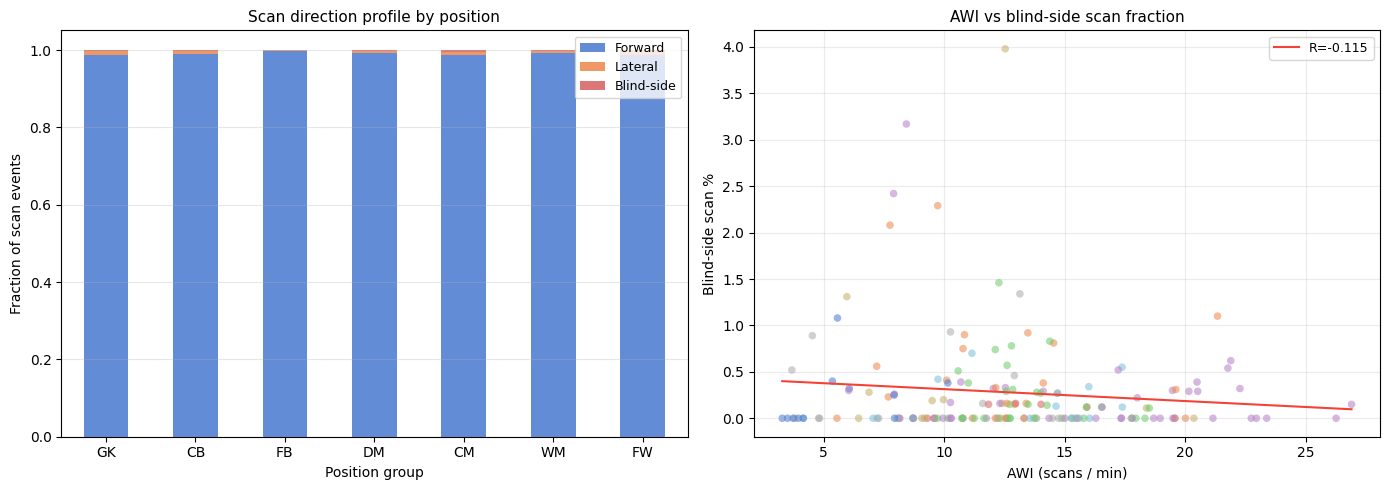

Saved: ../figures/awi_scan_direction.png


In [6]:
# Cell 15: Scan direction profile analysis
import scipy.stats as stats

BLIND_COL = "scan_blindside_pct"
if BLIND_COL not in df.columns:
    print("[SKIP] scan_blindside_pct not in data. Run unified pipeline (Cell 2 of run_pipeline.ipynb).")
else:
    dir_cols = ["scan_forward_pct", "scan_lateral_pct", "scan_blindside_pct"]
    dir_active = active[active[dir_cols[0]].notna()].copy()
    print(f"Rows with scan direction data: {len(dir_active)}")

    # Direction profile by position group
    dir_by_pos = (
        dir_active[dir_active["pos_group"].isin(GROUP_ORDER)]
        .groupby("pos_group")[dir_cols]
        .mean()
        .reindex(GROUP_ORDER)
        .round(3)
    )
    print("\nMean scan direction fractions by position group:")
    print(dir_by_pos.to_string())

    # Blind-side scan % vs AWI (correlation)
    valid_dir = dir_active[["awi_per_minute", BLIND_COL, "pos_group", "n_classified_scans"]].dropna()
    valid_dir = valid_dir[valid_dir["n_classified_scans"] >= 10]
    if len(valid_dir) > 5:
        r, p = stats.pearsonr(valid_dir["awi_per_minute"], valid_dir[BLIND_COL])
        print(f"\nCorrelation AWI vs blind-side %: R={r:.3f} (p={p:.3f}, n={len(valid_dir)})")

    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: Stacked bar , direction profile by position
    ax1 = axes[0]
    dir_by_pos.plot(kind='bar', stacked=True, ax=ax1,
                    color=['#4878d0', '#ee854a', '#d65f5f'], alpha=0.85)
    ax1.set_xlabel("Position group")
    ax1.set_ylabel("Fraction of scan events")
    ax1.set_title("Scan direction profile by position", fontsize=11)
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
    ax1.legend(["Forward", "Lateral", "Blind-side"], loc="upper right", fontsize=9)
    ax1.grid(axis='y', alpha=0.3)

    # Panel 2: Scatter , blind-side % vs AWI
    ax2 = axes[1]
    if len(valid_dir) > 5:
        scatter_colors = [colors[GROUP_ORDER.index(g)] if g in GROUP_ORDER else '#aaa'
                         for g in valid_dir['pos_group']]
        ax2.scatter(valid_dir['awi_per_minute'], valid_dir[BLIND_COL] * 100,
                    c=scatter_colors, alpha=0.55, s=30, edgecolors='none')
        m, b = np.polyfit(valid_dir['awi_per_minute'], valid_dir[BLIND_COL] * 100, 1)
        x_line = np.linspace(valid_dir['awi_per_minute'].min(), valid_dir['awi_per_minute'].max(), 100)
        ax2.plot(x_line, m * x_line + b, color='#F44336', lw=1.5,
                 label=f'R={r:.3f}' if len(valid_dir) > 5 else '')
        ax2.legend(fontsize=9)
    ax2.set_xlabel("AWI (scans / min)")
    ax2.set_ylabel("Blind-side scan %")
    ax2.set_title("AWI vs blind-side scan fraction", fontsize=11)
    ax2.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig("../figures/awi_scan_direction.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: ../figures/awi_scan_direction.png")


## Match Moments , Top Pre-Scan Passes

For each match, the top-5 moments where a player's pre-pass scanning activity was highest.
These are the broadcast-ready highlights: *"Kimmich scanned 4 times in the 5s before his assist at minute 67."*

Requires `results/match_moments.csv` , generated by the unified pipeline (Cell 2 of run_pipeline.ipynb).


In [7]:
# Cell 16: Match moments , highest pre-pass scanning moments per match

MOMENTS_PATH = "../results/match_moments.csv"
if not os.path.exists(MOMENTS_PATH):
    print(f"[SKIP] {MOMENTS_PATH} not found.")
    print("Run Cell 2 in run_pipeline.ipynb (unified pipeline) to generate match moments.")
else:
    moments_df = pd.read_csv(MOMENTS_PATH)
    print(f"Match moments loaded: {len(moments_df)} rows across {moments_df['match_id'].nunique()} matches")

    # Top moments overall
    top = moments_df.sort_values("pre_pass_scan_count", ascending=False).head(20)
    print("\nTop 20 pre-pass scanning moments:")
    print(top[["match_id", "name", "phase_label", "minute",
               "pre_pass_scan_count", "window_coverage"]].to_string(index=False))

    # Per-match top-5
    print("\n--- Top 5 moments per match ---")
    for match_id, grp in moments_df.groupby("match_id"):
        top5 = grp.nlargest(5, "pre_pass_scan_count")
        print(f"\n{match_id}:")
        for _, row in top5.iterrows():
            print(f"  min {row['minute']:5.1f}  {row['name']:30s}  "
                  f"{int(row['pre_pass_scan_count'])} scans in 5s pre-pass  "
                  f"({row['phase_label']})")


Match moments loaded: 25 rows across 5 matches

Top 20 pre-pass scanning moments:
match_id                   name phase_label  minute  pre_pass_scan_count  window_coverage
 FCB-HSV  Joshua Walter Kimmich    2nd half    23.6                    9              1.0
 SGE-FCU  Oscar Winther Höjlund    2nd half    25.8                    8              1.0
 SGE-FCU        Nathaniel Brown    2nd half    48.6                    8              1.0
 FCB-HSV          Konrad Laimer    1st half    11.3                    7              1.0
 FCB-HSV      Jonathan Glao Tah    1st half     6.7                    7              1.0
 FCB-HSV           Warmed Omari    2nd half    28.5                    7              1.0
 FCU-FCB       Aljoscha Kemlein    2nd half     5.5                    7              1.0
 FCU-FCB  Joshua Walter Kimmich    1st half     0.2                    7              1.0
 SGE-FCU  Oscar Winther Höjlund    2nd half    16.5                    7              1.0
 SGE-FCU  Arthur N